In [23]:
# load reqd. libs
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# enable GPU access
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Spot-Testing saved checkpoint

In [5]:
# recreate architecture --> load checkpoint
model = models.alexnet(weights = None)
model.classifier[6] = nn.Linear(4096, 1)

# load saved weights
checkpoint = torch.load('frozen_model.pth', map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [6]:
# test transforms
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])


In [ ]:
# spot-tests
img_path = "test1.jpg"

image = Image.open(img_path).convert("RGB")
input_tensor = test_transforms(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    prob = torch.sigmoid(output).item()

print("Rotten probability:", prob)

if prob > 0.5:
    print("Prediction: Fresh")
else:
    print("Prediction: Rotten")

Rotten probability: 6.589954137936616e-10
Prediction: Rotten


### Grad-CAM visualization to determine model trustworthiness

In [211]:
# load and process test image
test_path = 'dataset/test/good_quality/good_quality_62.jpg'
test_img = cv2.imread(test_path)
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_tensor = test_transforms(
    Image.fromarray(test_img)   # stays uint8
).unsqueeze(0).to(device)

# for gradcam viz.
input_size = (224, 224)
vis_img = cv2.resize(test_img, input_size)
vis_img = vis_img.astype(np.float32) / 255.0

test_tensor = test_transforms(Image.fromarray(test_img)).unsqueeze(0).to(device)

In [212]:
# applying gradcam on the last conv. feature extraction layer
last_feat_extract = [model.features[10]]
grad_cam = GradCAM(
    model = model,
    target_layers = last_feat_extract
)

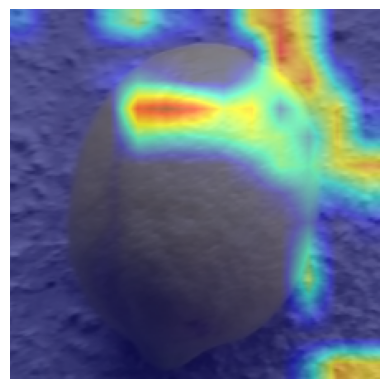

In [213]:
# generate CAM & visualize
targets = [BinaryClassifierOutputTarget(1)]
grayscale_cam = grad_cam(
    input_tensor = test_tensor,
    targets = targets
)

grayscale_cam = grayscale_cam[0]

visualization = show_cam_on_image(
    vis_img,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(visualization)
plt.axis("off")
plt.show()
